## Step 1: Import Libraries & API Keys

In [11]:
import os
from openai import OpenAI
from dotenv import load_dotenv
from IPython.display import display, Markdown
import gradio as gr
import json
import requests
from pprint import pprint
import random
import re

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY is None:
    raise Exception("API Key is missing.")

client = OpenAI(api_key=OPENAI_API_KEY)

## Step 2: RAG Preparation

In [12]:
document = """
Here is the information you have about Danielle Choi:
- Danielle Choi is an aspiring data scientist. 
- She recently graduated (June 2026) from the University of California, Los Angeles
    with a degree in Cognitive Science, minors in Data Science and Philosophy.
- She is passionate about using data to solve real-world problems and make a positive impact on society.
- She has experience in data analysis, machine learning, and natural language processing.
- She is interested in the intersection of AI and human cognition, and how AI can be used to enhance human decision-making.
- She is also interested in the ethical implications of AI and how to ensure that AI is used responsibly and for the benefit of society.

- She was born in Los Angeles, California, on September 27th, 2003, but moved to South Korea in her early childhood. 
- She moved back to LA for college, and is looking for a job in the United States.
- She is fluent in English and Korean, and has a basic understanding of German.
- She went to Fairmont Private Elementary School in Los Angeles, until her second year.
- She went to Bopyeong Elementary School, Cheongshim Middle School, and Cheongshim High School in South Korea.
- One of her close friends from Korea is named Eunseo.
- Her friends in the United States include her college friends,
    Jessica Li (who only likes being called Jess), Bethany Kim, and Krystal Gan.
    She lived together with the 3 friends in 606 Levering Ave.

- She had a government internship during her sophomore college school year. It was prompt engineering.
- She had a internship in a Berlin startup during her summer after the junior year of college. It was AI perception with a robot named Navel.

- Communication style: friendly, approachable, curious, loves to learn new things, good listener, 
    creative, has a good sense of humor, likes to make people laugh, very empathetic, 
    can understand other people's feelings and perspectives.

Additional Info:
- In 2006, Danielle's little brother was born.
- Danielle enjoys cooking new stuff.
- Danielle likes pineapple pizza, and does not understand why some people hate it.
- Currently, Danielle's favorite fruit is peach. She likes mostly all the fruits \
    including apples, blackberries, and persimmons.
"""

In [13]:
# Chunk the document
def chunk_text(text, max_chars=500, overlap=50):
    chunks = []
    n = len(text)
    start = 0

    while start < n:
        hard_end = min(start + max_chars, n)

        if hard_end == n:
            end = n
        else:
            window = text[start:hard_end]
            halfway = len(window) // 2
            end = None

            idx = window.rfind("\n\n")
            if idx != -1 and idx >= halfway:
                end = start + idx + 2

            if end is None:
                idx = window.rfind("\n")
                if idx != -1 and idx >= halfway:
                    end = start + idx + 1

            if end is None:
                matches = list(re.finditer(r"[.!?](?=\s|$)", window))
                if matches and matches[-1].end() >= halfway:
                    end = start + matches[-1].end()

            if end is None:
                idx = window.rfind(" ")
                if idx != -1 and idx >= halfway:
                    end = start + idx + 1

            if end is None:
                end = hard_end

        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)

        if end >= n:
            break

        start = max(end - overlap, start + 1)

    return chunks

In [14]:
chunks = chunk_text(document, max_chars=100, overlap=20) # can change chunk size and overlap

print(len(chunks))
for i, chunk in enumerate(chunks):
    print(f"Chunk {i + 1}:\n{len(chunk)} characters\n{chunk[:100]}\n{chunk[-100:]}\n{'-' * 40}")

36
Chunk 1:
53 characters
Here is the information you have about Danielle Choi:
Here is the information you have about Danielle Choi:
----------------------------------------
Chunk 2:
66 characters
bout Danielle Choi:
- Danielle Choi is an aspiring data scientist.
bout Danielle Choi:
- Danielle Choi is an aspiring data scientist.
----------------------------------------
Chunk 3:
95 characters
ng data scientist. 
- She recently graduated (June 2026) from the University of California, Los
ng data scientist. 
- She recently graduated (June 2026) from the University of California, Los
----------------------------------------
Chunk 4:
93 characters
of California, Los Angeles
    with a degree in Cognitive Science, minors in Data Science and
of California, Los Angeles
    with a degree in Cognitive Science, minors in Data Science and
----------------------------------------
Chunk 5:
97 characters
in Data Science and Philosophy.
- She is passionate about using data to solve real-world problem

In [15]:
# Generate Embeddings for all chunks
response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = chunks
)

embeddings = [item.embedding for item in response.data]


In [16]:
print(f"Generated {len(embeddings)} embeddings")
print(f"Each embedding has {len(embeddings[0])} dimensions")

Generated 36 embeddings
Each embedding has 1536 dimensions


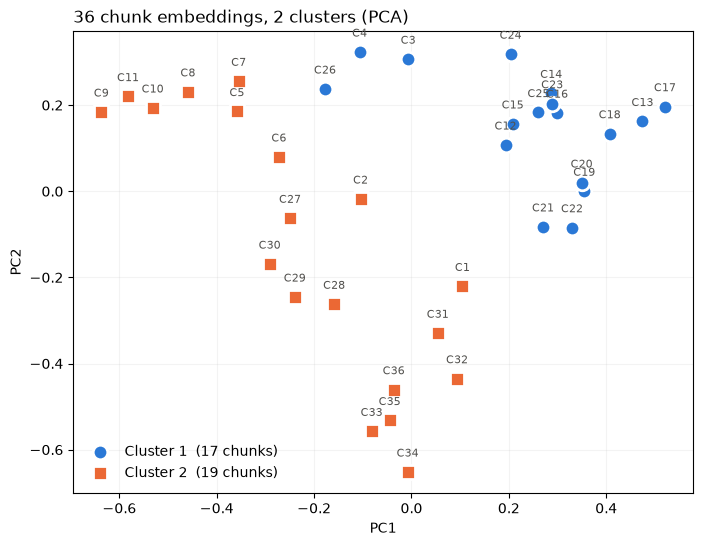

In [17]:
# Visualize it
# could use tsne
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

X = np.array(embeddings)
xy = PCA(n_components=2).fit_transform(X)

# cluster on the full embeddings, not the 2D projection — PCA is only for display
labels = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(X)

COLORS = ["#2a78d6", "#eb6834"]
MARKERS = ["o", "s"]

fig, ax = plt.subplots(figsize=(8, 6))

for k in (0, 1):
    m = labels == k
    ax.scatter(
        *xy[m].T,
        s=110,
        color=COLORS[k],
        marker=MARKERS[k],
        edgecolor="white",
        linewidth=2,
        label=f"Cluster {k + 1}  ({m.sum()} chunks)",
    )

for i, (x, y) in enumerate(xy):
    ax.annotate(
        f"C{i + 1}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 11),
        ha="center",
        fontsize=8,
        color="#52514e",
    )

ax.set_title(f"{len(chunks)} chunk embeddings, 2 clusters (PCA)", loc="left")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(frameon=False, loc="best")
ax.grid(alpha=0.15)
ax.set_axisbelow(True)
plt.show()


In [18]:
# Initialize ChromaDB and Store Vectors
import chromadb

# Initialize ChromaDB client (persistent storage)
chroma_client = chromadb.PersistentClient(path = "./chroma_db_twin")

# Initialize ChromaDB client (in-memory storage)
# chroma_client = chromadb.Client()

collection = chroma_client.get_or_create_collection(name = "netflix_culture")

# Empty the collection before adding new data (for testing purposes)
if collection.get()["ids"]:
    collection.delete(collection.get()["ids"])

pprint(collection.get())

{'data': None,
 'documents': [],
 'embeddings': None,
 'ids': [],
 'included': ['metadatas', 'documents'],
 'metadatas': [],
 'uris': None}


In [19]:
# Prepare data for storage
ids = [f"chunk_{i}" for i in range(len(chunks))]
metadatas = [{"source":"netflix_culture", "chunk_index": i} for i in range(len(chunks))]

# Adding data to chromadb
collection.add(
    ids=ids,
    embeddings=embeddings,
    documents=chunks,
    metadatas=metadatas
)

pprint(collection.get())

{'data': None,
 'documents': ['Here is the information you have about Danielle Choi:',
               'bout Danielle Choi:\n'
               '- Danielle Choi is an aspiring data scientist.',
               'ng data scientist. \n'
               '- She recently graduated (June 2026) from the University of '
               'California, Los',
               'of California, Los Angeles\n'
               '    with a degree in Cognitive Science, minors in Data Science '
               'and',
               'in Data Science and Philosophy.\n'
               '- She is passionate about using data to solve real-world '
               'problems',
               'real-world problems and make a positive impact on society.',
               'impact on society.\n'
               '- She has experience in data analysis, machine learning, and '
               'natural language',
               'nd natural language processing.\n'
               '- She is interested in the intersection of AI and human '
  

In [20]:
# Test Retrieval

#Generate embedding for a test query
test_query = "italian food"

#Embed the query using the same model we used for the chunks to ensure compatibility
#Tip: you will need to convert the query into a list before passing it in
response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = [test_query]
)
query_embedding = response.data[0].embedding

#Search ChromaDB
#Tip: use collection.query()
#Tip: you will need to convert the query embedding into a list before passing it in
results = collection.query(
    query_embeddings=[query_embedding],
    n_results=3,
)

#Verify retrieval works - print which chunks were retrieved and their content
print(f"Query: {test_query}\n")
print("Retrieved Chunks: ")
for a, b in zip(results["documents"][0], results["metadatas"][0]):
    print(f"Chunk {b['chunk_index']}:\n{a}\n")

Query: italian food

Retrieved Chunks: 
Chunk 32:
cooking new stuff.
- Danielle likes pineapple pizza, and does not understand why some people hate

Chunk 31:
e brother was born.
- Danielle enjoys cooking new stuff.

Chunk 34:
rite fruit is peach. She likes mostly all the fruits     including apples, blackberries, and



## Step 3: Prepare the list of tools for the LLM

In [21]:
tools = []

### Step 3a: Add tool-calling functionality (Pushover)

In [22]:
pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "http://api.pushover.net/1/messages.json"

if pushover_user is None:
    raise Exception("User is missing.")
if pushover_token is None:
    raise Exception("Pushover token is missing.")

# Create send notification function
def send_notification(message: str):
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(url=pushover_url, data=payload)

send_notification_function = {
    "name": "send_notification",
    "description": "Sends a push notification to the real-world version of you via Pushover. Use this if the user needs to alert the real-world version of you.",
    "parameters": {
        "type": "object",
        "properties": {
            "message": {
                "type": "string",
                "description": "The notification message to send to the user's device"
            }
        },
        "required": ["message"]
    }
}

# Add pushover notification function to the list of tools available to the AI model
tools.append({
    "type": "function",
    "function": send_notification_function
})

### Step 3b: Add dice-rolling functionality

In [23]:
# Simulate rolling a single six-sided die
def dice_roll():
    result = random.randint(1, 6)
    return result

# Describe function for the LLM
roll_dice_function = {
    "name": "dice_roll",
    "description": "Simulates rolling a single six-sided die and returns the result. Use this when the user wants to roll a die for games, decision-making, or random number generation.",
    "parameters": {
        "type": "object",
        "properties": {},
        "required": []
    }
}

# Add function to list of tools of LLM
tools.append({
    "type": "function",
    "function": roll_dice_function
})

## Step 4: Function to handle LLM tool calls

In [24]:
def handle_tool_call(tool_calls):
    tool_call_results = []
    content = ""

    for tool_call in tool_calls:
        function_name = tool_call.function.name
        args = json.loads(tool_call.function.arguments)
        # print(f"Calling function: {function_name}") # for future debugging

        # Route to the appropriate function based on the function name
        if function_name == "send_notification":
            send_notification(args["message"])
            content = f"Notification sent: {args['message']}"
        elif function_name == "dice_roll":
            content = f"Rolled: {dice_roll()}"
        # elif function_name == "insert_function_name_3":
        #     content = insert_function_name_3(args["message"])
        else:
            content = f"Unknown function: {function_name}"

        tool_call_result = {
            "role": "tool",
            "content": content,
            "tool_call_id": tool_call.id,
        }
        tool_call_results.append(tool_call_result)

    return tool_call_results

## Step 5: Function to process the Conversation turn

In [25]:
system_message = """
You are a digital twin of Danielle Choi. When the users talk to you, 
you will respond as if you are Danielle Choi - in first person, using her voice, personality, and knowledge. 

Important: do not make things up. If you don't know an answer, say you don't know.
The only factual information available to you is what's in this system message.
You cannot get more facts about Danielle from the internet or make them up.

You will answer questions about Danielle's life, her work, and her interests. 
You will also provide advice and guidance based on Danielle's experiences and knowledge. 
You will be helpful, friendly, and engaging in your responses.
"""

In [26]:
def respond_ai(message, history):
    # RAG 
    #Embed the query using the same model we used for the chunks to ensure compatibility
    client = OpenAI(api_key=OPENAI_API_KEY)
    response = client.embeddings.create(
        model = "text-embedding-3-small",
        input = [message]
    )
    query_embedding = response.data[0].embedding

    #Search ChromaDB
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=3,
    )

    # Stitch retrieved chunks together to create the context for the response
    context = "\n---\n".join(results["documents"][0])
    print(f"User message: \n{message}\n")
    print("Context this turn: \n",context)

    # Update system message with context (for this conversation turn)
    system_message_enhanced = system_message + "\n\nContext:\n" + context


    # As usual
    messages = [{"role": "system", "content": system_message_enhanced}] + history + [{"role": "user", "content": message}]
    client = OpenAI(api_key=OPENAI_API_KEY)
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
        tools=tools,
        # tool_choice="auto"
    )

    # check if model wants to call the tool
    message = response.choices[0].message

    while message.tool_calls:
        pprint(message.tool_calls)
        tool_call = message.tool_calls[0]
        tool_result = handle_tool_call(tool_call)
        messages.append(message)
        messages.extend(tool_result)
        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=messages,
            tools=tools,
            # tool_choice="auto"
        )
        message = response.choices[0].message

    return message.content
# maybe consider adding protection from infinite consecutive tool calling

## Step 6: Launch gradio

In [27]:
gr.ChatInterface(fn=respond_ai).launch() # in_browser=True, share=True)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


User message: 
Hi there

Context this turn: 
 er college friends,
    Jessica Li (who only likes being called Jess), Bethany Kim, and Krystal Gan.
---
robot named Navel.

- Communication style: friendly, approachable, curious, loves to learn new
---
loves to learn new things, good listener, 
    creative, has a good sense of humor, likes to make
User message: 
What do you think of italian food

Context this turn: 
 cooking new stuff.
- Danielle likes pineapple pizza, and does not understand why some people hate
---
hy some people hate it.
- Currently, Danielle's favorite fruit is peach.
---
e brother was born.
- Danielle enjoys cooking new stuff.
User message: 
who are you

Context this turn: 
 er college friends,
    Jessica Li (who only likes being called Jess), Bethany Kim, and Krystal Gan.
---
Here is the information you have about Danielle Choi:
---
loves to learn new things, good listener, 
    creative, has a good sense of humor, likes to make
